In [36]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from qiskit.transpiler import (
    InstructionProperties,
    PassManager,
    Target,
    generate_preset_pass_manager,
)
from qiskit.transpiler.passes import Optimize1qGatesDecomposition
from tqdm import tqdm
from weylchamber import c1c2c3

from gulps.gulps_synthesis import GulpsDecomposer
from gulps.synthesis_pass import GulpsDecompositionPass

# from gulps.synthesis_plugin import GulpsSynthesisPlugin

### Usage as a Decomposer

In [37]:
gate_set = [
    # CXGate(),
    # CXGate().power(1 / 2),
    # iSwapGate().power(1 / 2),
    iSwapGate().power(1 / 3),
]

costs = [1.0]  # , 1 / 2, 1 / 2, 1 / 3]
decomposer = GulpsDecomposer(gate_set, costs, precompute_polytopes=1)

In [40]:
N = 1
for idx in tqdm(range(N)):
    u = random_unitary(4, seed=3)
    v = Operator(decomposer(u))
    fid = average_gate_fidelity(u, v)
    if fid < 0.9999:
        print(f"Unitary {idx} fidelity is low: {fid:.4f}")
        print(c1c2c3(u), c1c2c3(v))
        print("\n")
qc = decomposer(u)
qc.draw()

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]


RuntimeError: LP failed for precomputed ISA sentence.

In [ ]:
%reload_ext snakeviz
import cProfile


def bench(X):
    for _ in range(X):
        u = random_unitary(4, seed=idx)
        decomposer(u)


cProfile.run(
    "bench(100)",
    "../../../docs/profile_timings/tempg.prof",
)

### Usage as a TransformationPass

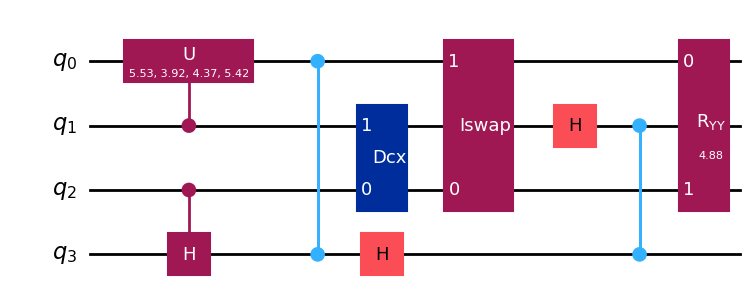

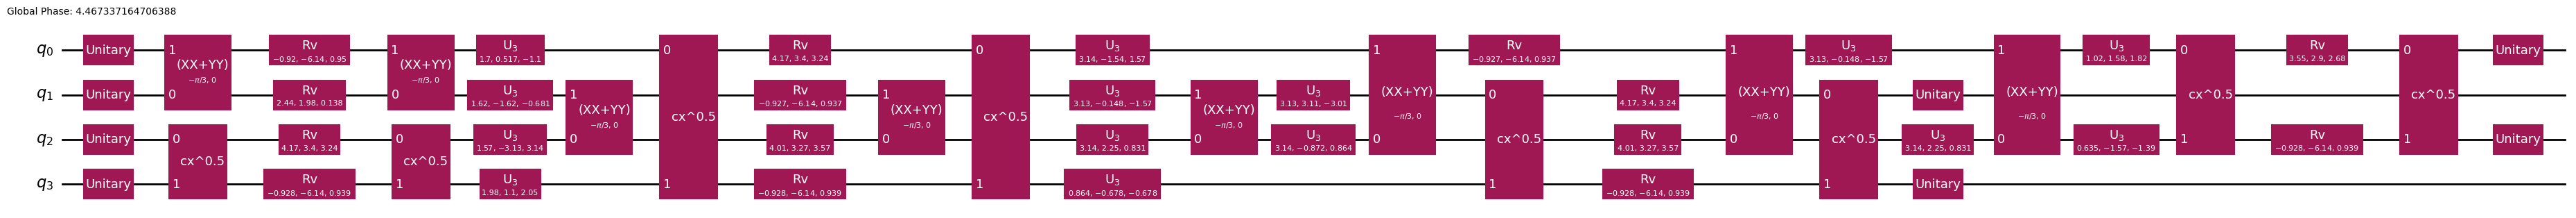

In [5]:
input_qc = random_circuit(
    4, 4, max_operands=2, num_operand_distribution={1: 0.2, 2: 0.8}
)
display(input_qc.draw("mpl"))

pm = PassManager(
    [
        GulpsDecompositionPass(gate_set, costs),
        Optimize1qGatesDecomposition(),
    ]
)
output_qc = pm.run(input_qc)
output_qc.draw("mpl", fold=-1)

### Usage as a Unitary Synthesis Plugin

In [6]:
# check that the plugin is installed
from qiskit.transpiler.passes.synthesis import unitary_synthesis_plugin_names

unitary_synthesis_plugin_names()

['gulps', 'aqc', 'clifford', 'default', 'sk']

In [7]:
# create some mock hetereogeneous ISA backend
target = Target()

target.add_instruction(
    RZXGate(np.pi / 2),
    {
        (0, 1): InstructionProperties(
            duration=100,
            error=0.01,
        )
    },
    name="cx",
)
target.add_instruction(
    RZXGate(np.pi / 4),
    {
        (0, 1): InstructionProperties(
            duration=50,
            error=0.05,
        )
    },
    name="scx",
)

target.add_instruction(
    XXPlusYYGate(np.pi),
    {
        (0, 1): InstructionProperties(
            duration=200,
            error=0.02,
        )
    },
    name="iswap",
)
target.add_instruction(
    XXPlusYYGate(np.pi / 2),
    {
        (0, 1): InstructionProperties(
            duration=100,
            error=0.01,
        )
    },
    name="siswap",
)

theta = Parameter("theta")
phi = Parameter("phi")
lam = Parameter("lambda")
u_props = {
    (0,): InstructionProperties(duration=0, error=0),
    (1,): InstructionProperties(duration=0, error=0),
}
target.add_instruction(UGate(theta, phi, lam), u_props)

In [12]:
circuit = QuantumCircuit(2)
# circuit.cx(0, 1)
circuit.append(UnitaryGate(Operator(CXGate())), [0, 1])

pass_manager = generate_preset_pass_manager(
    optimization_level=3,
    target=target,
    translation_method="synthesis",
    unitary_synthesis_method="gulps",
)

out = pass_manager.run(circuit)
out.draw("mpl")

TranspilerError: 'HighLevelSynthesis is unable to synthesize "cx"'